# Axisymmetric radiative heat transfer

Create the input fields, run the C++ solver, and visualize the result.

In [2]:
from pathlib import Path
import subprocess
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'radi.cpp').exists():
    raise FileNotFoundError('Start Jupyter from the repository directory.')

## Input fields

In [53]:
# a simpler example
# ni, nj = 120, 160
# radius, length = 0.5, 1.0  # m
# r_edges = np.linspace(0.0, radius, ni + 1)
# z_edges = np.linspace(0.0, length, nj + 1)
# r = 0.5 * (r_edges[:-1] + r_edges[1:])
# z = 0.5 * (z_edges[:-1] + z_edges[1:])
# R, Z = np.meshgrid(r, z, indexing='xy')

# # Replace these expressions to define another case.
# temperature = 800.0 + 900.0 * np.exp(-((R / 0.25)**2 + ((Z - 0.4) / 0.3)**2))  # K
# kappa = 0.05 + 0.35 * (Z / length)  # 1/m

# fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
# for ax, field, title, unit in [ (axes[0], temperature, 'Temperature', 'K'), (axes[1], kappa, 'Absorption coefficient', '1/m') ]:
#     image = ax.pcolormesh(r_edges, z_edges, field, shading='auto', cmap='inferno')
#     fig.colorbar(image, ax=ax, label=unit)
#     ax.set(title=title, xlabel='r [m]', ylabel='z [m]', aspect='equal')
# plt.show()

Grid: 500 x 250 cells
T: 491.4 to 1900.0 K
H2O: 0.0009 to 0.1700
CO2: 0.0003 to 0.0904
kappa: 0.0290 to 2.3952 1/m


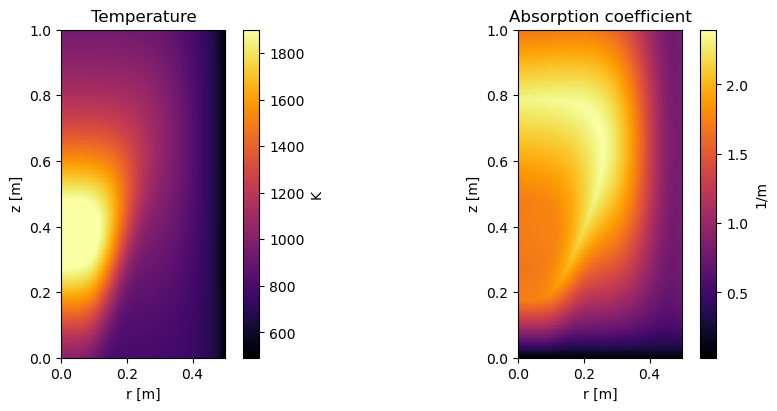

In [48]:
ni, nj = 500, 250
radius, length = 0.5, 1.0

r_edges = np.linspace(0.0, radius, ni + 1)
z_edges = np.linspace(0.0, length, nj + 1)

r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])
R, Z = np.meshgrid(r_centers, z_centers, indexing="xy")

# Dimensionless coordinates
rn = R / radius
zn = Z / length

# ------------------------------------------------------------
# 1. More boiler-like temperature field
# ------------------------------------------------------------

T_wall = 400.0       # K: effective near-wall gas temperature
T_inlet = 750.0      # K
T_peak = 1900.0      # K: typical hot flame-region value

# Flame radius grows downstream
flame_radius = 0.12 + 0.18 * zn

# Elongated flame core
flame_axial = np.exp(-((zn - 0.35) / 0.28)**2)
flame_radial = np.exp(-(R / flame_radius)**4)
flame = flame_axial * flame_radial

# Hot combustion products downstream of the flame
products = ( np.exp(-((zn - 0.65) / 0.45)**2) * np.exp(-(rn / 0.78)**6) )
temperature = ( T_inlet + 1050.0 * flame + 350.0 * products )

# Cooling close to the boiler wall
wall_layer = np.exp(-(radius - R) / 0.035)
temperature = ( T_wall + (temperature - T_wall) * (1.0 - 0.75 * wall_layer) )
temperature = np.clip(temperature, T_wall, T_peak)

# ------------------------------------------------------------
# 2. Approximate combustion-product concentrations
# ------------------------------------------------------------
burned_fraction = np.clip(0.15 + 0.85 * (flame + products), 0.0, 1.0)

# Example for natural-gas combustion with some excess air
x_h2o = 0.015 + 0.155 * burned_fraction
x_co2 = 0.0004 + 0.090 * burned_fraction

# Optional reduction near the cold incoming-gas region
mixing_progress = 1.0 - np.exp(-zn / 0.08)
x_h2o *= mixing_progress
x_co2 *= mixing_progress

# ------------------------------------------------------------
# 3. Grey-gas absorption coefficient
# ------------------------------------------------------------

pressure_atm = 1.0

# Illustrative Planck-mean-like correlations.
# These are placeholders and should be replaced with coefficients
# from a selected radiation model or spectral database.
theta = np.clip(temperature / 1000.0, 0.5, 2.5)

K_h2o = 8.0 * theta**(-0.7)   # 1/(m atm mole fraction)
K_co2 = 13.0 * theta**(-0.5)  # 1/(m atm mole fraction)

p_h2o = pressure_atm * x_h2o
p_co2 = pressure_atm * x_co2

kappa_gas = K_h2o * p_h2o + K_co2 * p_co2

# Optional soot contribution; use only if soot is relevant
fv_soot = 1e-7 * R
kappa_soot = 3.6e6 * fv_soot * temperature / 1500.0

kappa = np.clip(kappa_gas + kappa_soot, 1.0e-4, 20.0)

print(f"Grid: {ni} x {nj} cells")
print(f"T: {temperature.min():.1f} to {temperature.max():.1f} K")
print(f"H2O: {x_h2o.min():.4f} to {x_h2o.max():.4f}")
print(f"CO2: {x_co2.min():.4f} to {x_co2.max():.4f}")
print(f"kappa: {kappa.min():.4f} to {kappa.max():.4f} 1/m")

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
for ax, field, title, unit in [ (axes[0], temperature, 'Temperature', 'K'), (axes[1], kappa, 'Absorption coefficient', '1/m') ]:
    image = ax.pcolormesh(r_edges, z_edges, field, shading='auto', cmap='inferno')
    fig.colorbar(image, ax=ax, label=unit)
    ax.set(title=title, xlabel='r [m]', ylabel='z [m]', aspect='equal')
plt.show()

## Write the solver input

In [49]:
with (ROOT / 'problem_input.dat').open('w', encoding='utf-8') as stream:
    stream.write(f'{ni} {nj}\n')
    np.savetxt(stream, r_edges[None, :], fmt='%.16e')
    np.savetxt(stream, z_edges[None, :], fmt='%.16e')
    values = np.column_stack((temperature.ravel(), kappa.ravel()))
    np.savetxt(stream, values, fmt='%.16e')

## Build and run

In [50]:
executable = ROOT / 'radiative_dom.o'
subprocess.run([ 'g++', '-std=c++17', '-O2' , 'radi.cpp', '-o', str(executable) ], cwd=ROOT, check=True)
run = subprocess.run([str(executable)], cwd=ROOT, check=True, text=True, capture_output=True)
print(run.stdout)

Loaded problem_input.dat
Solved 125000 cells
Qr sum   = -6.88799e+10 W/m^3 (unweighted cell sum)
Qr range = [-3.89572e+06, 40915.5] W/m^3
Wrote QrFV.plt



## Result

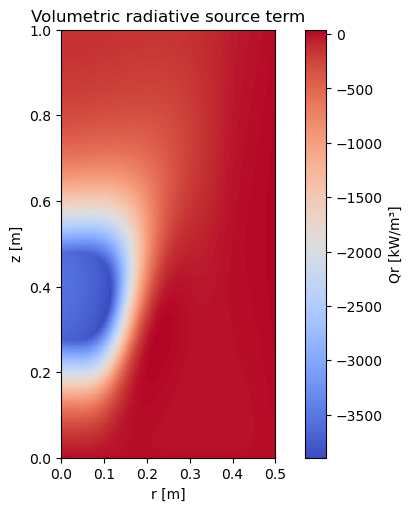

In [51]:
data = np.loadtxt(ROOT / 'QrFV.plt', skiprows=2)
Qr = data[:, 2].reshape(nj, ni)

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
image = ax.pcolormesh(r_edges, z_edges, Qr / 1000.0, shading='auto', cmap='coolwarm')
fig.colorbar(image, ax=ax, label='Qr [kW/m³]')
ax.set(title='Volumetric radiative source term', xlabel='r [m]', ylabel='z [m]', aspect='equal')
plt.show()

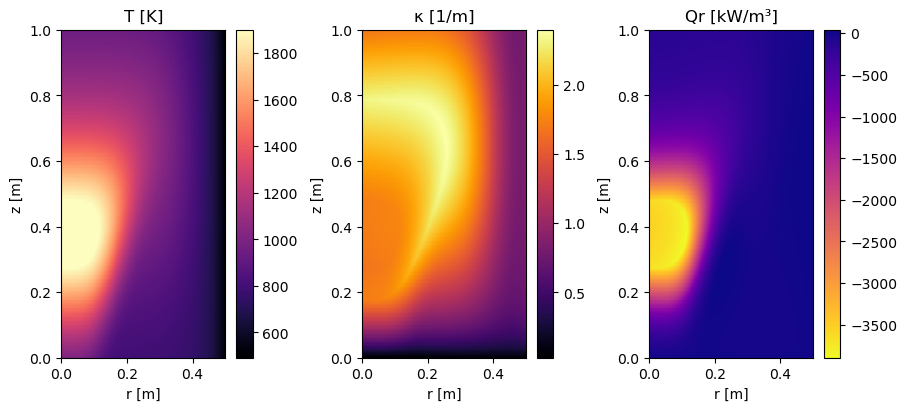

In [52]:
# fig, axes = plt.subplots(1, 3, figsize=(9, 4), constrained_layout=True )
# for ax, field, title, color_map in [ (axes[0], temperature, 'T [K]', "magma" ), (axes[1], kappa, 'κ [1/m]', "inferno"), (axes[2], Qr/1000, 'Qr [kW/m³]', "plasma_r") ]:
#     image = ax.pcolormesh(r_edges, z_edges, field, shading='auto', cmap=color_map)
#     fig.colorbar(image, ax=ax )
#     ax.set(title=title, xlabel='r [m]', ylabel='z [m]', aspect='equal')

# plt.savefig(str(ROOT/'results.png'), dpi=700)
# plt.show()